# 03 — Exploration du framework CLIMADA

**Objectif** : comprendre l'architecture et les concepts fondamentaux de [CLIMADA](https://wcr.ethz.ch/research/climada.html) (CLIMate ADAptation), le framework open-source développé par le Weather and Climate Risks group (ETH Zurich, Prof. David N. Bresch).

CLIMADA modélise le risque climatique selon la chaîne classique :

$$\text{Risk} = f(\text{Hazard}, \text{Exposure}, \text{Vulnerability})$$

Ce notebook explore chaque composant avec des exemples concrets.

---

**Sommaire** :
1. Architecture et concepts
2. Hazard — modélisation d'un aléa (tropical cyclone)
3. Exposure — définition d'un portefeuille d'actifs
4. ImpactFuncSet — fonctions de vulnérabilité
5. Impact — calcul du risque
6. Adaptation — mesures et coût-bénéfice

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from climada.hazard import Hazard, Centroids, TCTracks, TropCyclone
from climada.entity import Entity, Exposures, ImpactFuncSet, ImpfTropCyclone, MeasureSet
from climada.engine import Impact, CostBenefit

print("Imports OK — CLIMADA prêt à l'emploi")

Imports OK — CLIMADA prêt à l'emploi


## 1. Architecture CLIMADA

CLIMADA repose sur 4 composants principaux :

| Composant | Classe | Description |
|-----------|--------|-------------|
| **Hazard** | `Hazard` | Événements climatiques (intensité × localisation × fréquence) |
| **Exposure** | `Exposures` | Actifs exposés (localisation, valeur, type) |
| **Vulnerability** | `ImpactFuncSet` | Fonctions d'impact (intensité → fraction de dommage) |
| **Impact** | `Impact` | Résultat = convolution des 3 composants ci-dessus |

L'architecture est modulaire : chaque composant peut être sérialisé en HDF5, partagé, et combiné librement.

```
Hazard ──────┐
              ├──→ Impact.calc() ──→ Expected Annual Impact (EAI)
Exposure ────┤                       Exceedance Frequency Curve
              │                       Impact per event
Vulnerability┘
```

## 2. Hazard — Cyclones tropicaux (exemple IBTrACS)

On utilise les données historiques IBTrACS pour générer un ensemble de cyclones tropicaux.
L'approche CLIMADA :
1. Charger les **tracks** historiques depuis IBTrACS
2. Définir des **centroids** (grille de calcul)
3. Calculer le **champ de vent** à chaque centroid pour chaque événement

2026-04-01 23:40:43,818 - climada.hazard.tc_tracks - WARNING - `correct_pres` is deprecated. Use `estimate_missing` instead.
Nombre de tracks chargées : 114


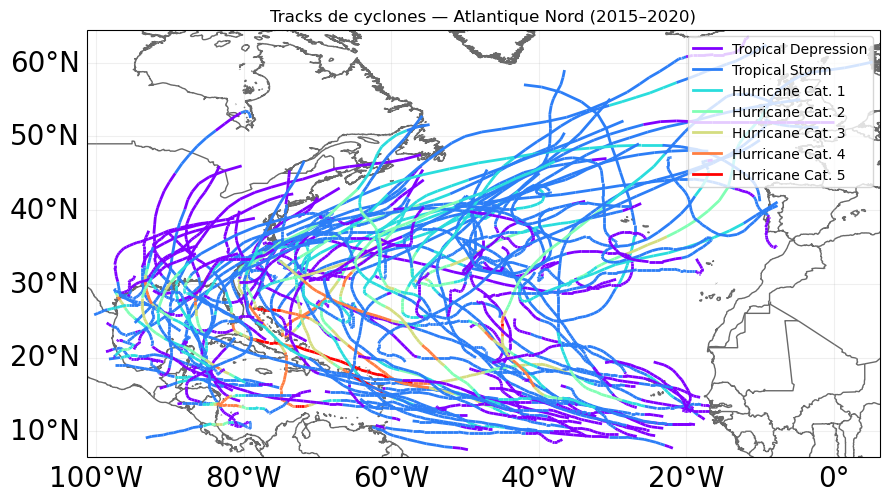

In [16]:
# --- 2a. Charger des tracks de cyclones depuis IBTrACS ---
# On se concentre sur le bassin Atlantique Nord, derniers événements majeurs
tracks = TCTracks.from_ibtracs_netcdf(
    basin='NA',           # North Atlantic
    year_range=(2015, 2020),
    correct_pres=True,
)
print(f"Nombre de tracks chargées : {tracks.size}")
tracks.plot()
plt.title("Tracks de cyclones — Atlantique Nord (2015–2020)")
plt.show()

Tracks après perturbation stochastique : 684


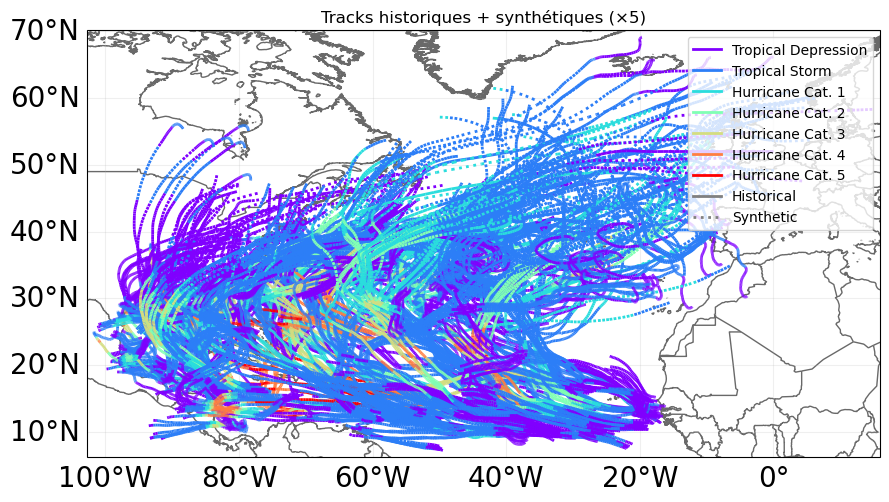

In [17]:
# --- 2b. Générer un set probabiliste par perturbation stochastique ---
# CLIMADA peut générer N tracks synthétiques par perturbation de chaque track historique
# C'est la base de l'analyse probabiliste du risque

# Les tracks IBTrACS ont des pas de temps irréguliers → on les uniformise d'abord
tracks.equal_timestep(time_step_h=1.0)

# decay=False : contourne un bug CLIMADA 6.1.0 × NumPy 2.x
# (la correction de décroissance terrestre plante sur float(array_1d))
tracks.calc_perturbed_trajectories(nb_synth_tracks=5, decay=False)
print(f"Tracks après perturbation stochastique : {tracks.size}")

# Visualiser les tracks historiques vs synthétiques
ax = tracks.plot()
ax.set_title("Tracks historiques + synthétiques (×5)")
plt.show()

In [18]:
# --- 2c. Calculer le hazard (champ de vent) sur une grille ---
# On définit des centroids sur les Caraïbes / côte Est US
# Puis on calcule l'intensité du vent max à chaque centroid pour chaque événement

# Centroids sur une grille régulière (résolution ~50 km)
min_lat, max_lat = 10, 35
min_lon, max_lon = -90, -60

centroids = Centroids.from_pnt_bounds(
    points_bounds=(min_lon, min_lat, max_lon, max_lat),
    res=0.5,  # ~50 km
)
print(f"Nombre de centroids : {centroids.size}")

# Calcul du hazard TC (vent max en m/s à chaque centroid)
tc_hazard = TropCyclone.from_tracks(tracks, centroids=centroids)
print(f"Hazard : {tc_hazard.size} événements × {tc_hazard.centroids.size} centroids")
print(f"Intensité max observée : {tc_hazard.intensity.max():.1f} m/s")

Nombre de centroids : 3111
Hazard : 684 événements × 3111 centroids
Intensité max observée : 70.5 m/s


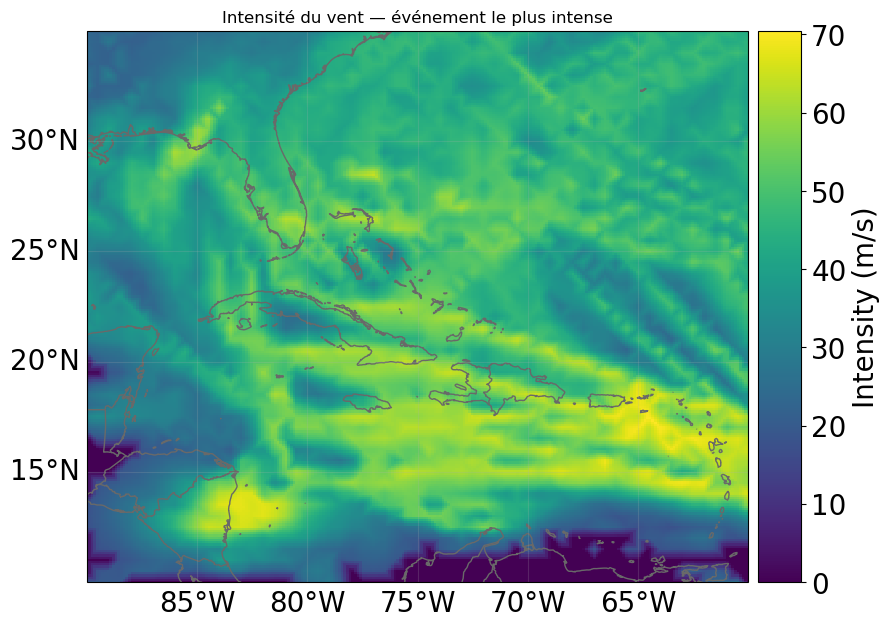

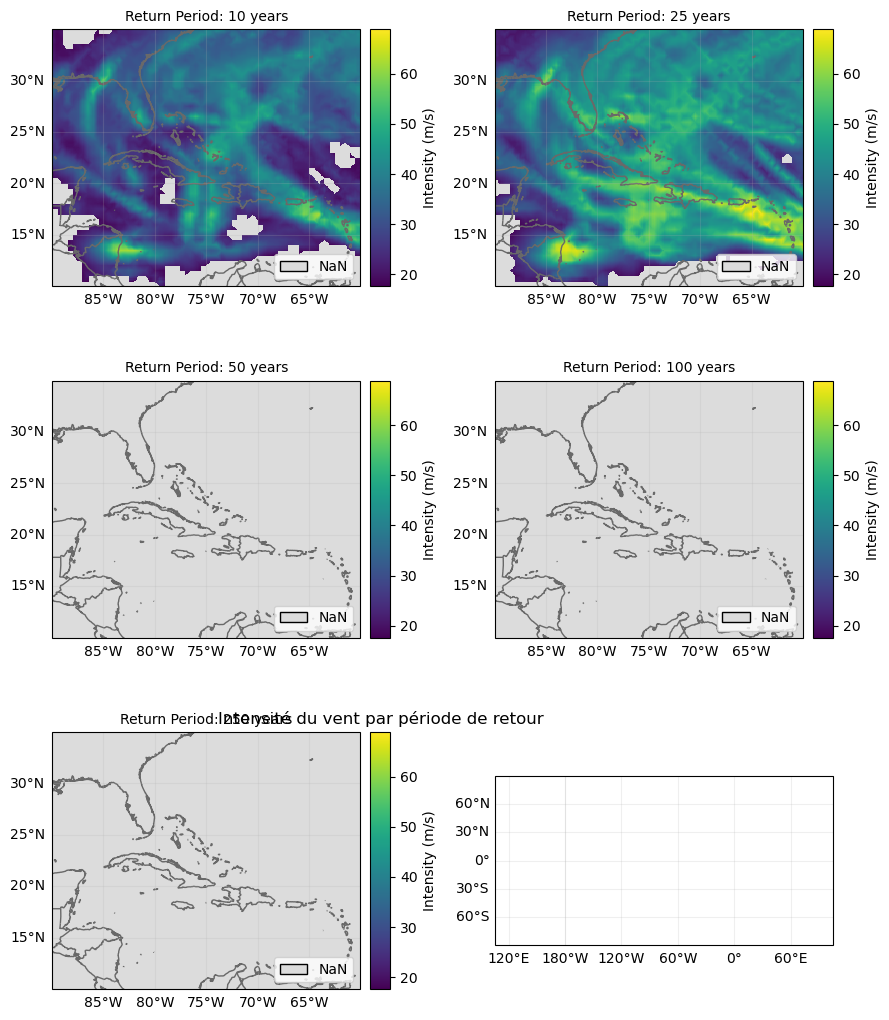

In [19]:
# --- 2d. Visualiser le hazard ---
# Carte d'intensité max tous événements confondus (Return Period plot)
ax = tc_hazard.plot_intensity(event=0)
ax.set_title("Intensité du vent — événement le plus intense")
plt.show()

# Courbe de fréquence-intensité à un point
tc_hazard.plot_rp_intensity(return_periods=[10, 25, 50, 100, 250])
plt.title("Intensité du vent par période de retour")
plt.show()

## 3. Exposure — Définition du portefeuille d'actifs exposés

`Exposures` est essentiellement un `GeoDataFrame` avec des colonnes obligatoires :
- `latitude`, `longitude` — localisation
- `value` — valeur de l'actif (€, $, nombre de personnes...)
- `impf_` — ID de la fonction d'impact à utiliser pour ce type d'aléa

CLIMADA fournit aussi des données d'exposition prêtes à l'emploi (LitPop = PIB × luminosité nocturne).

In [20]:
# --- 3a. Créer une exposition manuelle (portefeuille custom) ---
import geopandas as gpd
from shapely.geometry import Point

# Portefeuille d'actifs dans les Caraïbes
assets = [
    {"name": "Hotel Miami Beach",    "lon": -80.13, "lat": 25.79, "value": 50e6},
    {"name": "Port Kingston",        "lon": -76.80, "lat": 17.97, "value": 120e6},
    {"name": "Resort Cancún",        "lon": -86.85, "lat": 21.16, "value": 30e6},
    {"name": "Warehouse San Juan",   "lon": -66.07, "lat": 18.47, "value": 15e6},
    {"name": "Office Nassau",        "lon": -77.34, "lat": 25.06, "value": 25e6},
]

exp_gdf = gpd.GeoDataFrame(assets, geometry=[Point(a["lon"], a["lat"]) for a in assets])
exp_gdf["impf_TC"] = 1  # ID de la fonction d'impact pour cyclones tropicaux

exposure = Exposures(exp_gdf)
exposure.check()

print(f"Exposition totale : {exposure.gdf['value'].sum()/1e6:.0f} M$")
print(f"Nombre d'actifs : {len(exposure.gdf)}")

# Affichage avec coordonnées extraites de la geometry
display_df = exposure.gdf[["name", "value"]].copy()
display_df["longitude"] = exposure.gdf.geometry.x
display_df["latitude"] = exposure.gdf.geometry.y
display_df

Exposition totale : 240 M$
Nombre d'actifs : 5


,name,value,longitude,latitude
0,Hotel Miami Beach,50000000.0,-80.13,25.79
1,Port Kingston,120000000.0,-76.80,17.97
2,Resort Cancún,30000000.0,-86.85,21.16
3,Warehouse San Juan,15000000.0,-66.07,18.47
4,Office Nassau,25000000.0,-77.34,25.06


In [21]:
# --- 3b. Exposition pré-calculée LitPop (optionnel, téléchargement) ---
# LitPop = modèle d'exposition basé sur PIB × luminosité nocturne (satellite)
# Décommenter pour télécharger (peut prendre du temps)

# from climada.entity import LitPop
# litpop_jam = LitPop.from_countries(countries=['Jamaica'], fin_mode='gdp', res_arcsec=150)
# print(f"Jamaica — {litpop_jam.gdf.shape[0]} points, valeur totale : {litpop_jam.gdf['value'].sum()/1e9:.1f} Md$")
# litpop_jam.plot_hexbin()
# plt.title("LitPop Jamaica — distribution spatiale des actifs économiques")
# plt.show()

print("LitPop : modèle spatial d'exposition par pays (PIB × nightlights)")
print("→ Utile pour des analyses à l'échelle nationale sans portefeuille custom")

LitPop : modèle spatial d'exposition par pays (PIB × nightlights)
→ Utile pour des analyses à l'échelle nationale sans portefeuille custom


## 4. Vulnerability — Fonctions d'impact

Une **Impact Function** (anciennement "damage function") transforme l'intensité de l'aléa en fraction de dommage :

$$\text{MDD}(i) \times \text{PAA}(i) = \text{fraction de dommage}$$

- **MDD** (Mean Damage Degree) : dommage moyen relatif [0–1]
- **PAA** (Percentage of Affected Assets) : % d'actifs touchés [0–1]

CLIMADA fournit des fonctions calibrées pour chaque type d'aléa (Emanuel 2011 pour TC, JRC pour inondations, etc.).

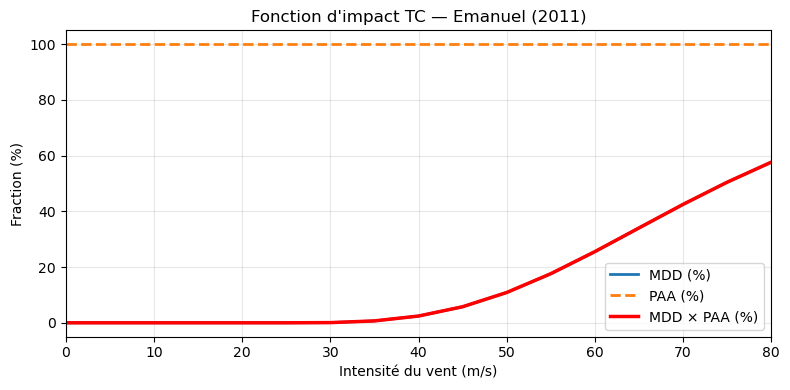

ID fonction : 1
Type d'aléa : TC
Intensité max : 120 m/s


In [22]:
# --- 4a. Fonction d'impact calibrée pour cyclones tropicaux (Emanuel 2011) ---
impf_tc = ImpfTropCyclone.from_emanuel_usa()

# Visualiser la fonction
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(impf_tc.intensity, impf_tc.mdd * 100, label="MDD (%)", linewidth=2)
ax.plot(impf_tc.intensity, impf_tc.paa * 100, label="PAA (%)", linewidth=2, linestyle="--")
ax.plot(impf_tc.intensity, impf_tc.mdd * impf_tc.paa * 100, label="MDD × PAA (%)",
        linewidth=2.5, color="red")
ax.set_xlabel("Intensité du vent (m/s)")
ax.set_ylabel("Fraction (%)")
ax.set_title("Fonction d'impact TC — Emanuel (2011)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()

print(f"ID fonction : {impf_tc.id}")
print(f"Type d'aléa : {impf_tc.haz_type}")
print(f"Intensité max : {impf_tc.intensity[-1]:.0f} m/s")

In [23]:
# --- 4b. Créer un ImpactFuncSet ---
# Le set contient toutes les fonctions nécessaires (une par type d'aléa × type d'actif)
impf_set = ImpactFuncSet([impf_tc])
print(impf_set)

## 5. Impact — Calcul du risque

C'est ici que tout se combine. `Impact.calc()` :
1. Assigne chaque point d'exposition au centroid le plus proche
2. Pour chaque événement, applique la fonction d'impact à l'intensité locale
3. Multiplie par la valeur de l'actif → dommage absolu (€)
4. Agrège sur tous les événements → **Expected Annual Impact (EAI)**

Métriques clés :
- **EAI** (Expected Annual Impact) = ∑ freq × impact par événement
- **AEP** (Annual Exceedance Probability) curve = probabilité de dépasser un seuil de perte

In [24]:
# --- 5a. Calcul de l'impact ---
impact = Impact()
impact.calc(exposures=exposure, impact_funcs=impf_set, hazard=tc_hazard, save_mat=True)

print(f"Expected Annual Impact (EAI) : {impact.aai_agg/1e6:.2f} M$")
print(f"Nombre d'événements : {impact.at_event.shape[0]}")
print(f"Impact max (événement unique) : {impact.at_event.max()/1e6:.2f} M$")
print(f"\nImpact par actif (EAI) :")
for i, row in exposure.gdf.iterrows():
    eai = impact.eai_exp[i]
    print(f"  {row['name']:25s} → {eai/1e3:>10.1f} k$/an  ({eai/row['value']*100:.2f}%)")

2026-04-01 23:41:24,330 - climada.engine.impact - WARNING - The use of Impact().calc() is deprecated. Use ImpactCalc().impact() instead.
Expected Annual Impact (EAI) : 1.81 M$
Nombre d'événements : 684
Impact max (événement unique) : 13.30 M$

Impact par actif (EAI) :
  Hotel Miami Beach         →      496.8 k$/an  (0.99%)
  Port Kingston             →      809.6 k$/an  (0.67%)
  Resort Cancún             →       53.9 k$/an  (0.18%)
  Warehouse San Juan        →      307.3 k$/an  (2.05%)
  Office Nassau             →      140.7 k$/an  (0.56%)


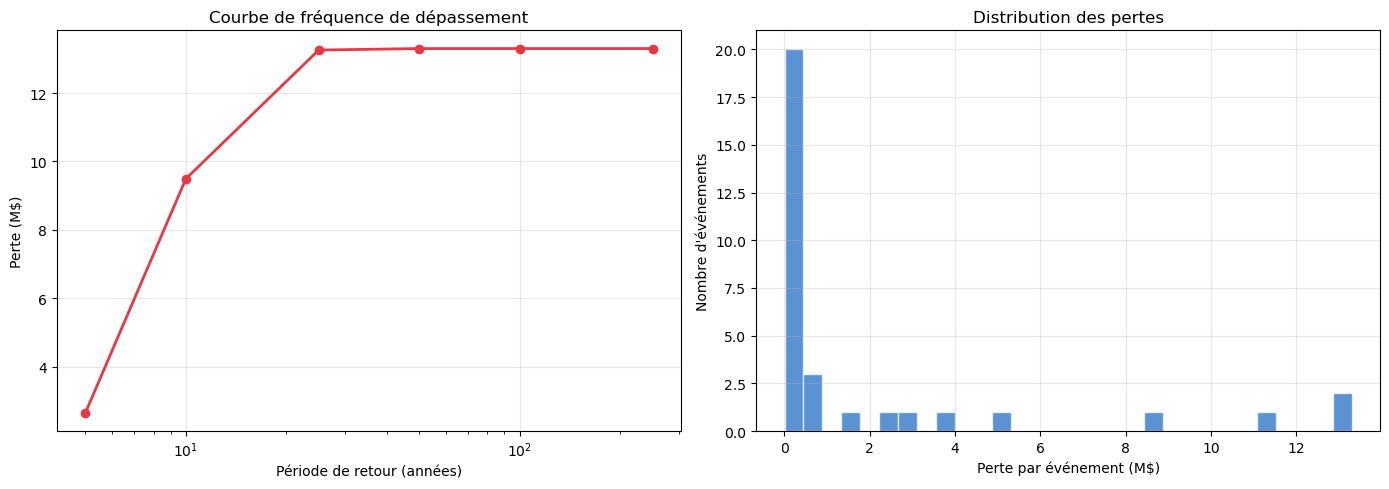

In [25]:
# --- 5b. Exceedance Frequency Curve ---
# La courbe EFC montre la probabilité annuelle de dépasser un niveau de perte donné
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de fréquence de dépassement
return_periods = np.array([5, 10, 25, 50, 100, 250])
rp_losses = impact.calc_freq_curve(return_per=return_periods)
axes[0].plot(rp_losses.return_per, rp_losses.impact / 1e6, 'o-', linewidth=2, color='#e63946')
axes[0].set_xlabel("Période de retour (années)")
axes[0].set_ylabel("Perte (M$)")
axes[0].set_title("Courbe de fréquence de dépassement")
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Distribution des pertes par événement
event_losses = impact.at_event[impact.at_event > 0]
axes[1].hist(event_losses / 1e6, bins=30, color='#1565C0', alpha=0.7, edgecolor='white')
axes[1].set_xlabel("Perte par événement (M$)")
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_title("Distribution des pertes")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Adaptation — Mesures et analyse coût-bénéfice

CLIMADA intègre un moteur d'analyse coût-bénéfice pour évaluer des **mesures d'adaptation** :
- Chaque mesure modifie soit le hazard, soit l'exposition, soit la vulnérabilité
- On compare le coût de la mesure au bénéfice (réduction de l'EAI)
- Le ratio coût-bénéfice permet de prioriser les investissements

Exemples de mesures :
- **Renforcement structurel** → réduit la vulnérabilité (décale la courbe d'impact)
- **Relocalisation** → réduit l'exposition
- **Digue / mangrove** → réduit le hazard

In [26]:
# --- 6a. Définir une mesure d'adaptation : renforcement structurel ---
from climada.entity import Measure

# Mesure : renforcement des bâtiments → réduit la vulnérabilité
# On modifie le MDD (Mean Damage Degree) via mdd_impact = (scale, shift)
# mdd_impact=(0.6, 0) → MDD * 0.6 (réduction de 40%)

measure_reinforce = Measure(
    name="Renforcement structurel",
    haz_type="TC",
    cost=20e6,                    # Coût total de la mesure (20 M$)
    mdd_impact=(0.6, 0),          # MDD * 0.6 → réduction de 40% des dommages
    paa_impact=(1, 0),            # PAA inchangé
    hazard_inten_imp=(1, 0),      # Intensité hazard inchangée
)

print(f"Mesure : {measure_reinforce.name}")
print(f"Coût : {measure_reinforce.cost/1e6:.0f} M$")
print(f"Effet : MDD × {measure_reinforce.mdd_impact[0]} → réduction de {(1-measure_reinforce.mdd_impact[0])*100:.0f}% du dommage moyen")

Mesure : Renforcement structurel
Coût : 20 M$
Effet : MDD × 0.6 → réduction de 40% du dommage moyen


## 7. Sérialisation et interopérabilité

CLIMADA utilise **HDF5** comme format natif pour tous ses objets. Cela permet :
- Partage reproductible des analyses
- Stockage compact des matrices creuses (hazard intensity)
- Versioning des datasets

In [27]:
# --- 7. Sauvegarder et recharger un hazard ---
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    haz_path = os.path.join(tmpdir, "tc_hazard.hdf5")
    
    # Sauvegarde
    tc_hazard.write_hdf5(haz_path)
    file_size = os.path.getsize(haz_path) / 1e6
    print(f"Hazard sauvegardé : {haz_path}")
    print(f"Taille : {file_size:.1f} MB")
    
    # Rechargement
    tc_reloaded = TropCyclone.from_hdf5(haz_path)
    print(f"Hazard rechargé : {tc_reloaded.size} événements, {tc_reloaded.centroids.size} centroids")
    print(f"Intégrité vérifiée : intensités identiques = {(tc_hazard.intensity != tc_reloaded.intensity).nnz == 0}")

Hazard sauvegardé : /var/folders/c3/rt282jkj30s7xj44zjhn23zc0000gp/T/tmpb_z3szab/tc_hazard.hdf5
Taille : 1.7 MB
Hazard rechargé : 684 événements, 3111 centroids
Intégrité vérifiée : intensités identiques = True


## 8. Récapitulatif — Architecture CLIMADA

| Concept | Classe | Ce qu'on a vu |
|---------|--------|---------------|
| Tracks | `TCTracks` | IBTrACS historiques + perturbation stochastique |
| Hazard | `TropCyclone` | Champ de vent sur grille de centroids |
| Exposure | `Exposures` | Portefeuille custom (GeoDataFrame) + LitPop |
| Vulnerability | `ImpfTropCyclone` | Emanuel 2011 (MDD × PAA) |
| Impact | `Impact` | EAI, courbe de fréquence, impact par actif |
| Adaptation | `Measure` | Renforcement structurel, coût-bénéfice |
| I/O | HDF5 | Sérialisation native |

### Points clés pour open_climate_risk :
- CLIMADA peut compléter notre approche Aqueduct pour les **cyclones, sécheresse, vagues de chaleur**
- Le moteur probabiliste (tracks synthétiques) est bien plus riche que notre approche par période de retour
- L'analyse coût-bénéfice est un différenciateur fort pour les clients
- Les données LitPop permettent des analyses sans portefeuille custom

### Prochaines étapes :
- [ ] Intégrer CLIMADA pour le flood risk (comparer avec notre approche Aqueduct)
- [ ] Explorer `climada.hazard.Flood` pour les inondations
- [ ] Tester l'API climat pour les projections futures
- [ ] Évaluer la cohérence entre les EAD Aqueduct et les EAI CLIMADA